# Package requirements

In [1]:
import matplotlib
import numpy
import pandas
import sklearn

print("matplotlib version:", matplotlib.__version__)
print("numpy version:", numpy.__version__)
print("pandas version:", pandas.__version__)
print("sklearn version:", sklearn.__version__)

/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


matplotlib version: 3.9.2
numpy version: 1.23.0
pandas version: 2.2.3
sklearn version: 1.5.2


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from sklearn.manifold import MDS

# function to perform mds
def perform_mds_on_dataset(csv_file):
    # Read the data
    data = pd.read_csv(csv_file)

    # Drop the 'pathway_name' column if it exists
    if 'pathway_name' in data.columns:
        data = data.drop('pathway_name', axis=1)

    # Ensure all data is numeric
    data = data.apply(pd.to_numeric, errors='coerce')

    # Drop rows with NaN values resulting from non-numeric data
    data = data.dropna()

    # Perform MDS
    mds = MDS(n_components=3, random_state=42)
    mds_data = mds.fit_transform(data.T)

    return mds_data

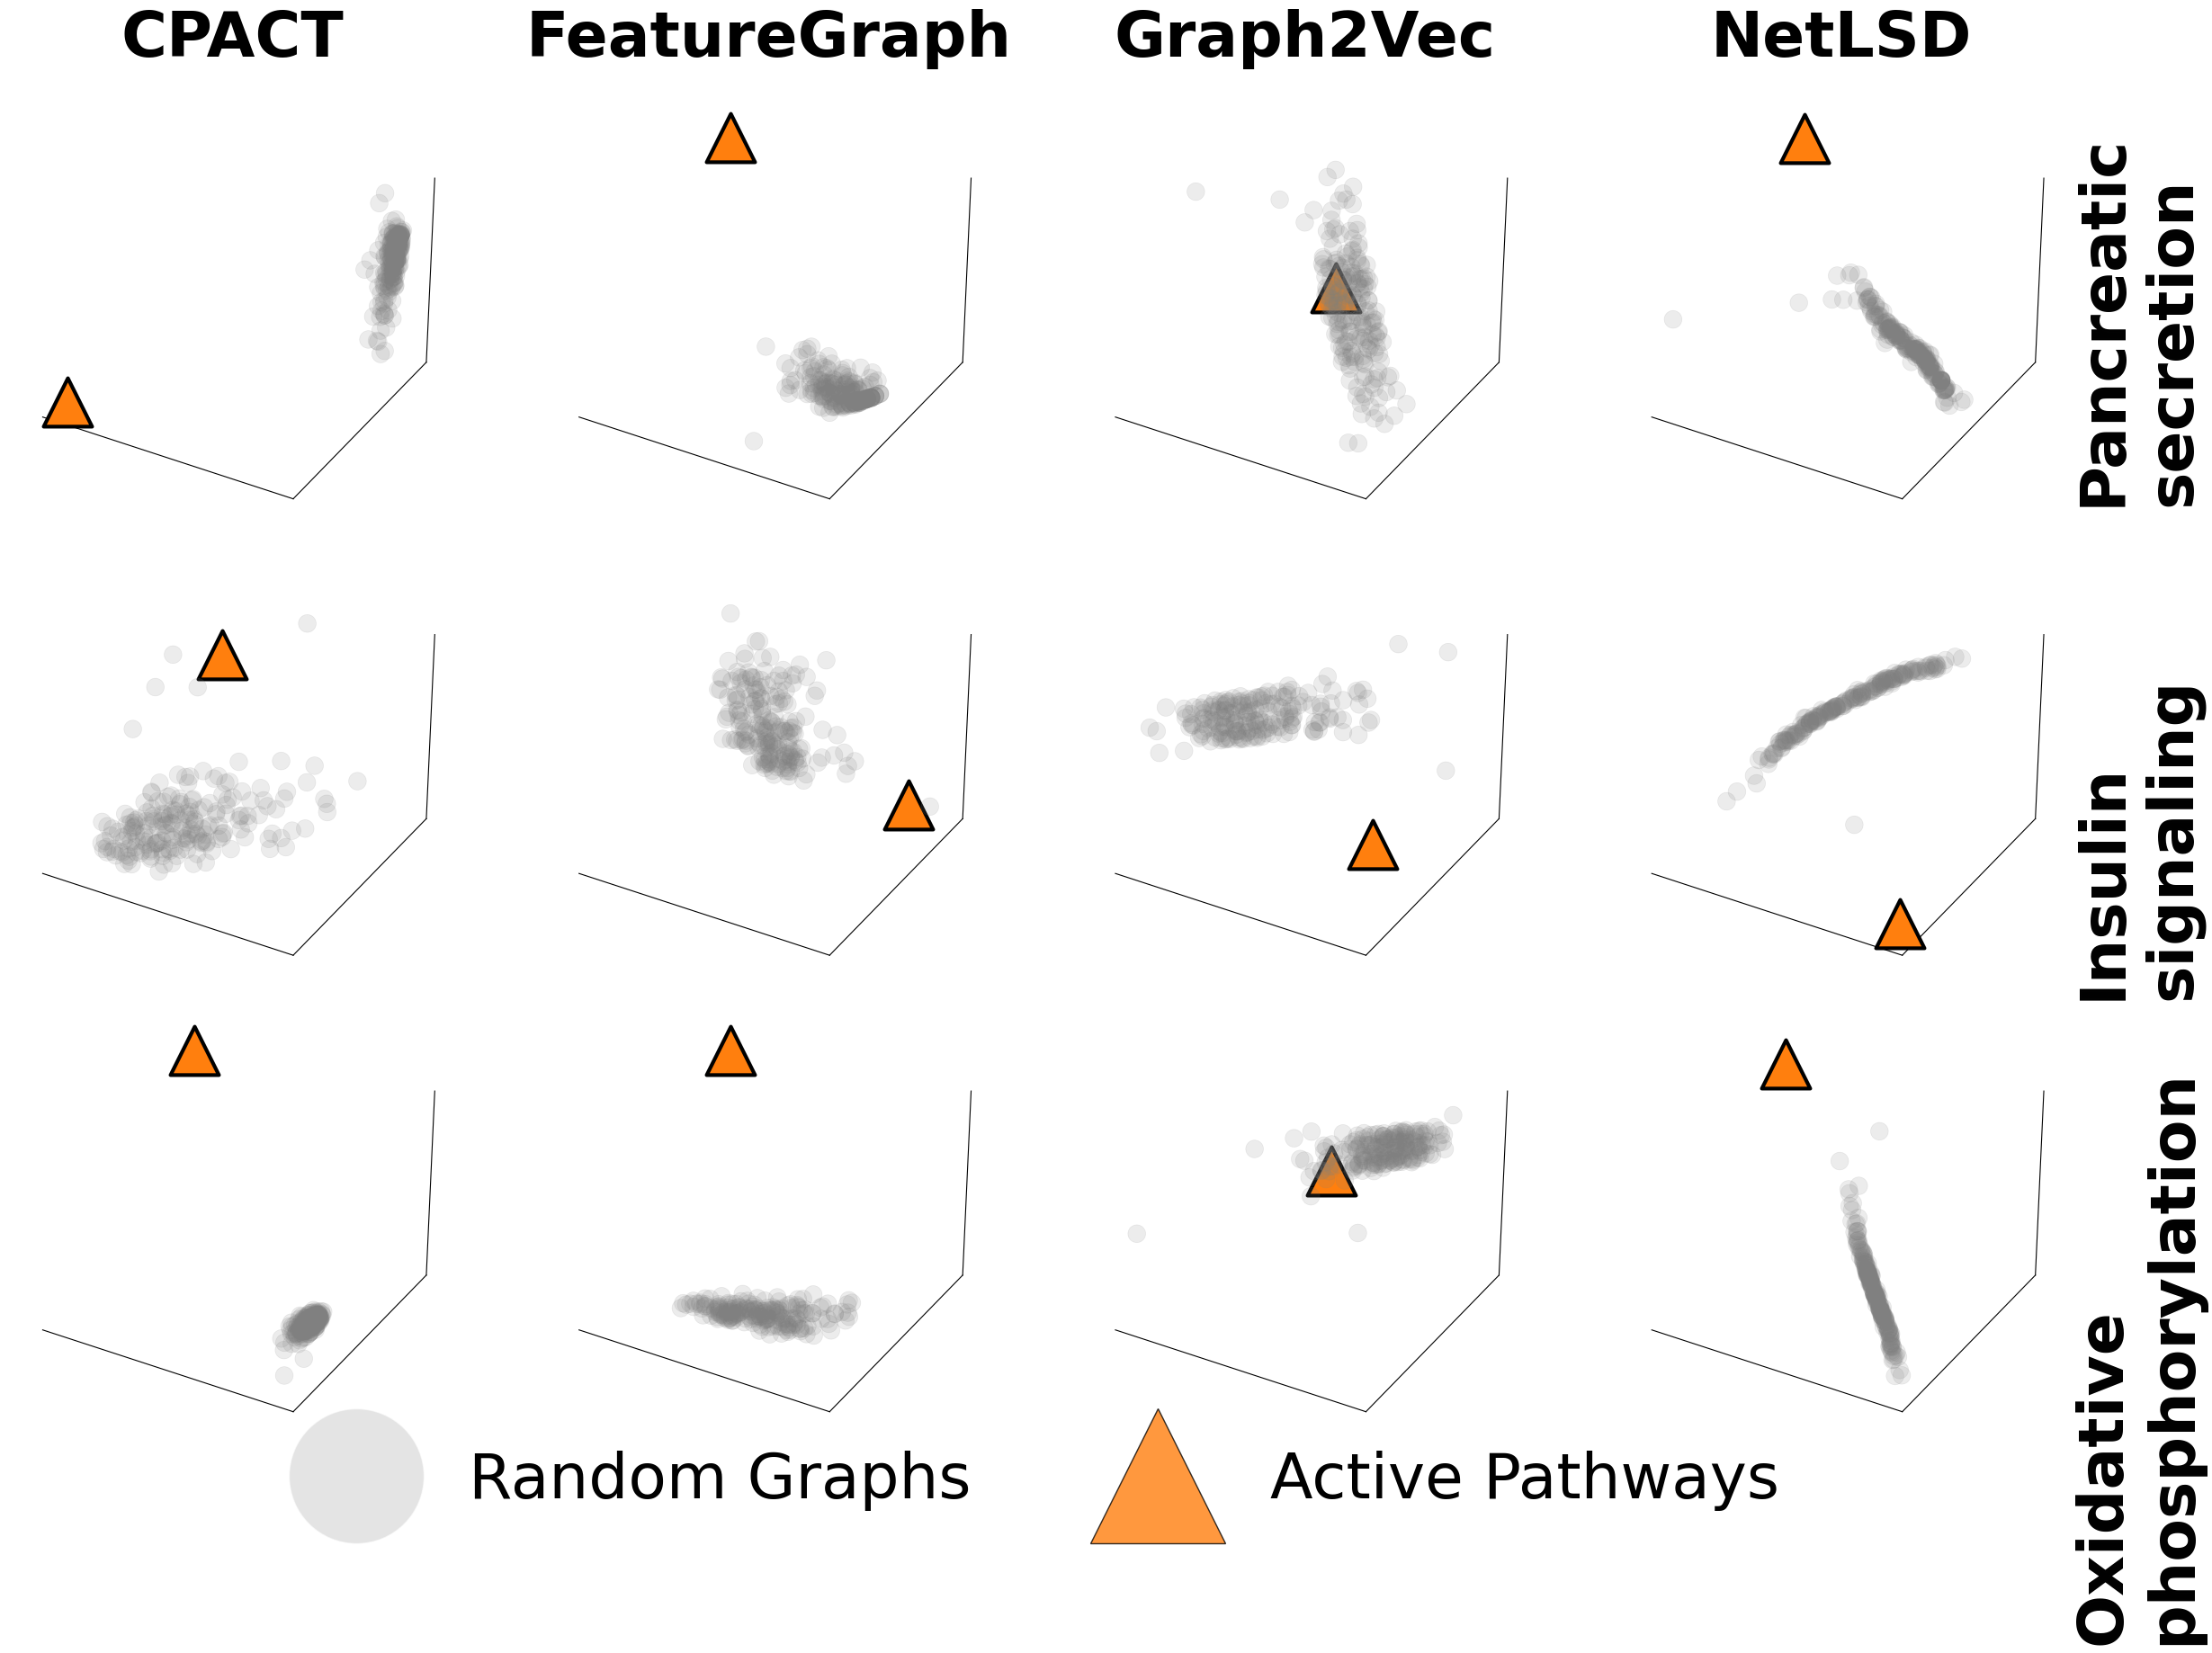

In [3]:
row_labels = ['Pancreatic secretion','Insulin signaling', 'Oxidative phosphorylation']
col_labels = ['CPACT', 'FeatureGraph', 'Graph2Vec', 'NetLSD']

# for the active ones
csv_files = ['Embeddings/Pancreatic secretion_CPACT_pancreas_embeddings.csv', 
             'Embeddings/Pancreatic secretion_FeatherGraph_pancreas_embeddings.csv', 
              'Embeddings/Pancreatic secretion_Graph2Vec_pancreas_embeddings.csv',
            'Embeddings/Pancreatic secretion_NetLSD_pancreas_embeddings.csv', 
            'Embeddings/Insulin signaling pathway_CPACT_pancreas_embeddings.csv', 
           'Embeddings/Insulin signaling pathway_FeatherGraph_pancreas_embeddings.csv', 
           'Embeddings/Insulin signaling pathway_Graph2Vec_pancreas_embeddings.csv', 
             'Embeddings/Insulin signaling pathway_NetLSD_pancreas_embeddings.csv', 
            'Embeddings/Oxidative phosphorylation_CPACT_pancreas_embeddings.csv', 
             'Embeddings/Oxidative phosphorylation_FeatherGraph_pancreas_embeddings.csv', 
             'Embeddings/Oxidative phosphorylation_Graph2Vec_pancreas_embeddings.csv',
            'Embeddings/Oxidative phosphorylation_NetLSD_pancreas_embeddings.csv']

# Create figure
fig = plt.figure(figsize=(24, 18))

ax_list = []

# Modify the pathway names to split into two lines
row_labels = [label.replace(' ', '\n') for label in row_labels]

# Update to create 3x4 grid of subplots
for i, csv_file in enumerate(csv_files):
    # Read the data
    data = perform_mds_on_dataset(csv_file)
    
    pathway_data = [data[0].tolist()]  # First row for pathway
    random_data = data[1:].tolist()  # Rest for random embeddings
    
    pathway_data = np.array(pathway_data)
    random_data = np.array(random_data)

    # Create subplot with 3x4 layout
    ax = fig.add_subplot(3, 4, i+1, projection='3d')
    ax_list.append(ax)

    # Set pane color
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.5))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.5))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.5))

    # Customize gridlines
    ax.xaxis._axinfo["grid"].update({"color": "grey", "linewidth": 0.1})
    ax.yaxis._axinfo["grid"].update({"color": "grey", "linewidth": 0.1})
    ax.zaxis._axinfo["grid"].update({"color": "grey", "linewidth": 0.1})
        
    # Scatter plots for random data and pathway data
    ax.scatter(random_data[:, 0], random_data[:, 1], random_data[:, 2], 
               alpha=0.15, s=200, linewidths=0.5, marker='o', color='grey', label='Random Graphs' if i % 4 == 0 else "")
    ax.scatter(pathway_data[:, 0], pathway_data[:, 1], pathway_data[:, 2], 
               s=1500, linewidths=3.0, edgecolors='black', marker='^', color='C1', label='Active Pathways' if i % 4 == 0 else "")

    # Set the title to the embedding technique
    if i < 4:
        ax.set_title(col_labels[i], fontsize=50, fontweight='bold', pad=20)  # Increased title font size

    # Remove axis ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

# Create custom legend handles
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Random Graphs',
           markerfacecolor='lightgrey', markersize=60, alpha=0.6),
    Line2D([0], [0], marker='^', color='w', label='Active Pathways',
           markerfacecolor='C1', markersize=60, markeredgewidth=1.0, markeredgecolor='black', alpha=0.8)
]

# Add the custom legend to the figure
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02),
           fancybox=False, shadow=False, ncol=2, edgecolor='none', fontsize=50, markerscale=1.8)

# Add row labels on the left side of the plots
for i in range(3):
    fig.text(0.98, 0.75 - i*0.32, row_labels[i], ha='left', va='center', fontsize=50, fontweight='bold', rotation='vertical')

# Adjust layout to prevent overlapping
plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# Save and show the plot
# plt.savefig('Active_comparison.jpg', bbox_inches='tight', dpi=400)
plt.show()

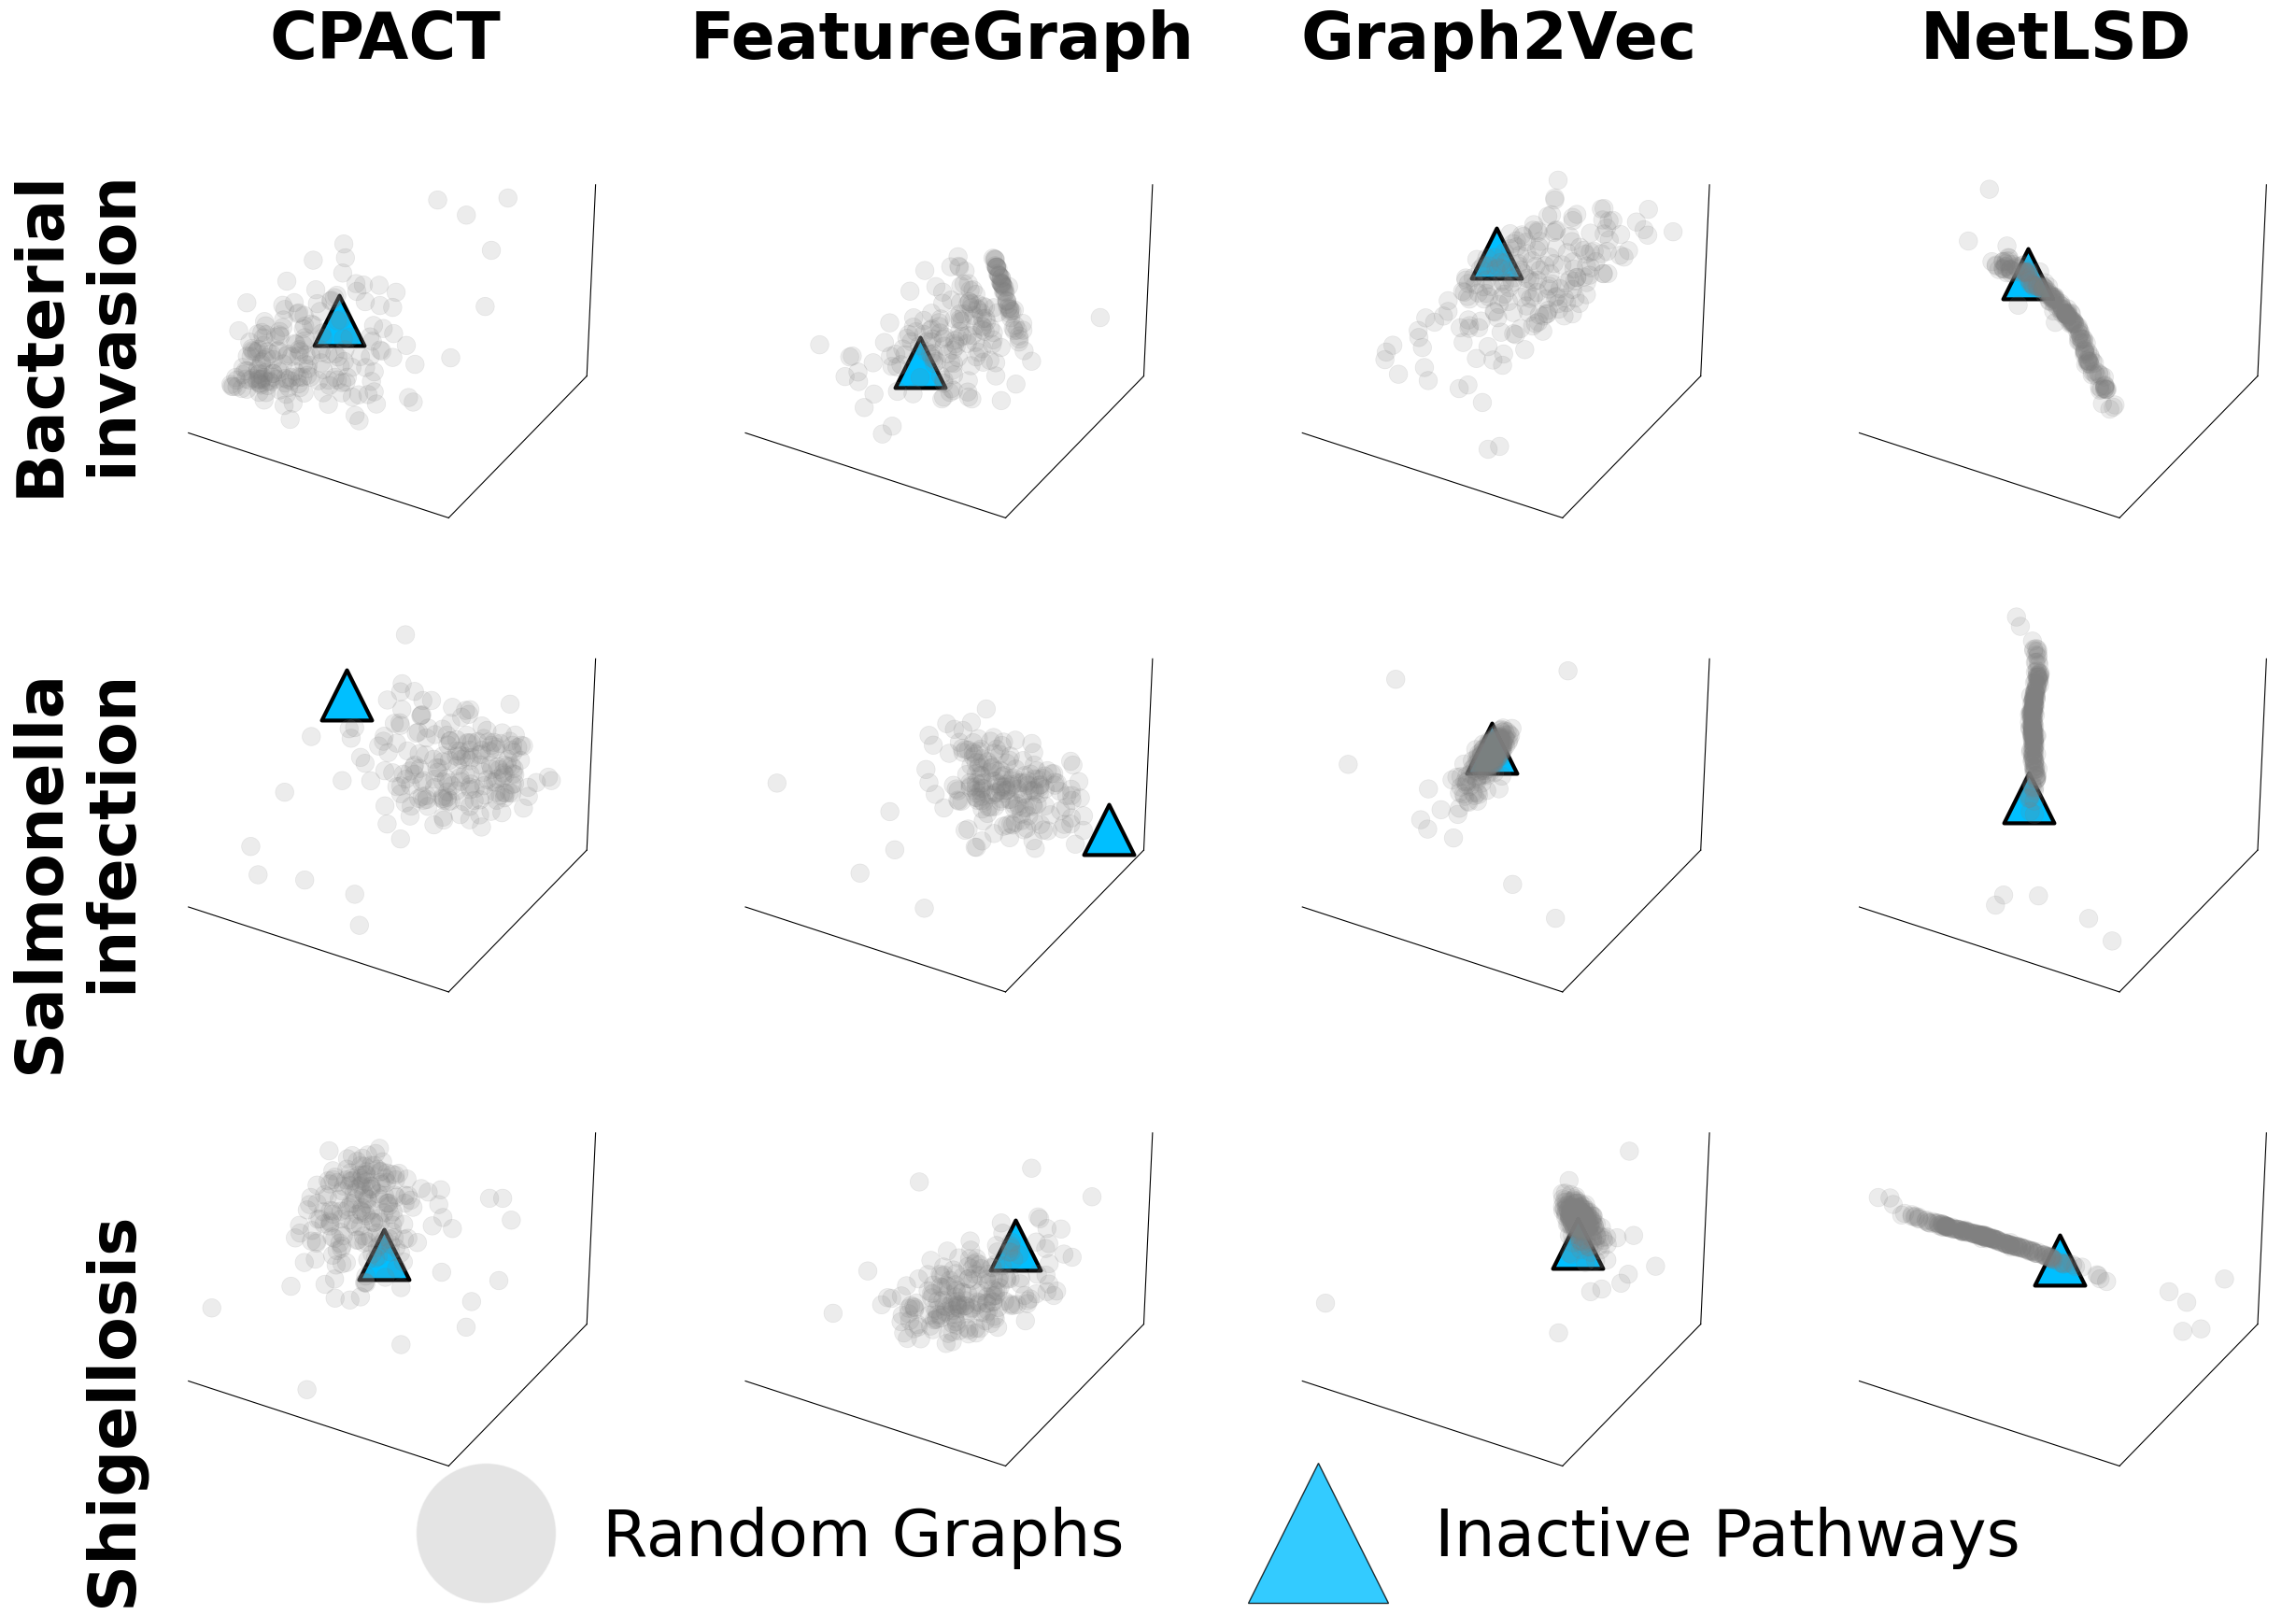

In [4]:
row_labels = ['Bacterial invasion', 'Salmonella infection', 'Shigellosis']
col_labels = ['CPACT', 'FeatureGraph', 'Graph2Vec', 'NetLSD']

# for the inactive ones
csv_files = [' Embeddings/Bacterial invasion of epithelial cells_CPACT_pancreas_embeddings.csv', 
             ' Embeddings/Bacterial invasion of epithelial cells_FeatherGraph_pancreas_embeddings.csv', 
            ' Embeddings/Bacterial invasion of epithelial cells_Graph2Vec_pancreas_embeddings.csv',
            ' Embeddings/Bacterial invasion of epithelial cells_NetLSD_pancreas_embeddings.csv', 
            ' Embeddings/Salmonella infection_CPACT_pancreas_embeddings.csv', 
            ' Embeddings/Salmonella infection_FeatherGraph_pancreas_embeddings.csv', 
            ' Embeddings/Salmonella infection_Graph2Vec_pancreas_embeddings.csv', 
             ' Embeddings/Salmonella infection_NetLSD_pancreas_embeddings.csv', 
            ' Embeddings/Shigellosis_CPACT_pancreas_embeddings.csv', 
             ' Embeddings/Shigellosis_FeatherGraph_pancreas_embeddings.csv', 
             ' Embeddings/Shigellosis_Graph2Vec_pancreas_embeddings.csv',
            ' Embeddings/Shigellosis_NetLSD_pancreas_embeddings.csv']

# Create figure
fig = plt.figure(figsize=(24, 18))

ax_list = []

# Modify the pathway names to split into two lines
row_labels = [label.replace(' ', '\n') for label in row_labels]

# Update to create 3x4 grid of subplots
for i, csv_file in enumerate(csv_files):
    # Read the data
    data = perform_mds_on_dataset(csv_file)
    
    pathway_data = [data[0].tolist()]  # First row for pathway
    random_data = data[1:].tolist()  # Rest for random embeddings
    
    pathway_data = np.array(pathway_data)
    random_data = np.array(random_data)

    # Create subplot with 3x4 layout
    ax = fig.add_subplot(3, 4, i+1, projection='3d')
    ax_list.append(ax)

    # Set pane color
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.5))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.5))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.5))

    # Customize gridlines
    ax.xaxis._axinfo["grid"].update({"color": "grey", "linewidth": 0.1})
    ax.yaxis._axinfo["grid"].update({"color": "grey", "linewidth": 0.1})
    ax.zaxis._axinfo["grid"].update({"color": "grey", "linewidth": 0.1})
        
    # Scatter plots for random data and pathway data
    ax.scatter(random_data[:, 0], random_data[:, 1], random_data[:, 2], 
               alpha=0.15, s=200, linewidths=0.5, marker='o', color='grey', label='Random Graphs' if i % 4 == 0 else "")
    ax.scatter(pathway_data[:, 0], pathway_data[:, 1], pathway_data[:, 2], 
               s=1500, linewidths=3.0, edgecolors='black', marker='^', color='deepskyblue', label='Inactive Pathways' if i % 4 == 0 else "")

    # Set the title to the embedding technique
    if i < 4:
        ax.set_title(col_labels[i], fontsize=50, fontweight='bold', pad=20)  # Increased title font size

    # Remove axis ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

# Create custom legend handles
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Random Graphs',
           markerfacecolor='lightgrey', markersize=60, alpha=0.6),
    Line2D([0], [0], marker='^', color='w', label='Inactive Pathways',
           markerfacecolor='deepskyblue', markersize=60, markeredgewidth=1.0, markeredgecolor='black', alpha=0.8)
]

# Add the custom legend to the figure
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02),
           fancybox=False, shadow=False, ncol=2, edgecolor='none', fontsize=50, markerscale=1.8)

# Add row labels on the left side of the plots
for i in range(3):
    fig.text(0.02, 0.75 - i*0.32, row_labels[i], ha='right', va='center', fontsize=50, fontweight='bold', rotation='vertical')

# Adjust layout to prevent overlapping
plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# Save and show the plot
# plt.savefig('Inactive_comparison.jpg', bbox_inches='tight', dpi=400)
plt.show()